# STREAMING SUBSCRIPTION CHURN RISK ANALYSIS: A DECISION TREE APPROACH
*Floriand Beshku -*
*2026*

### PREDICTIVE MODELING OF CUSTOMER CHURN IN STREAMING SERVICES: Decision Tree Analysis

This project demonstrates how data can be used to improve customer retention decisions by replacing intuition-based strategies with an objective, data-driven approach. Using a dataset of 1,000 streaming service users, was developed a decision tree model to predict the probability that a customer will cancel their subscription.

### Business Context:
Many subscription-based businesses rely on broad assumptions or intuition when managing customer retention, often resulting in inefficient use of resources and missed opportunities to prevent churn. Without a structured approach, retention efforts may target the wrong users or fail to identify those most at risk. Systematic, data-driven targeting is essential to improve retention and maximize customer lifetime value.

### Objective: 
Predict the likelihood of customer churn and identify the user behaviors and subscription characteristics that most strongly influence the decision to remain subscribed or cancel.

### Dataset Overview:
* Volume: 1,000 unique user records.
* Target Variable: Binary outcome (1 = Churned, 0 = Stayed).

### Key Variables: 
Watch hours per week, content views in the last 30 days, days since last login, monthly subscription fee, plan type, customer tenure, number of profiles.

### Methodology Workflow

| Step | Phase | Key Task |
| :--- | :--- | :--- |
| **01** | **Preparation** | Data cleaning, removal of identifiers, and encoding of categorical variables. |
| **02** | **Exploration** | Analysis of user engagement, inactivity, and subscription behavior patterns. |
| **03** | **Modeling** | Decision tree development to classify churn risk. |
| **04** | **Validation** | Data partitioning (Train/Validation/Test) for unbiased evaluation. |
| **05** | **Evaluation** | Performance metrics using confusion matrices and classification reports. |
| **06** | **Tuning** | Hyperparameter optimization to improve model performance. |
| **07** | **Interpretation** | Extraction of decision rules and feature importance for business insights. |

### Core Focus: Interpretability. 
While predictive performance is important, this model emphasizes interpretability and practical business value. By producing clear, rule-based segments and churn probabilities, the model enables management to identify high-risk users, understand the drivers of churn, and design targeted retention strategies aligned with business goals.

# Environment Setup

In [3]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm


# Load the Data

In [5]:
# read data
df = pd.read_csv('streamingv2.csv')

In [6]:
# how many rows and columns
df.shape

(1000, 9)

In [7]:
# Preview
print(df.head())

  customer_id  monthly_fee  watch_hours_per_week  days_since_last_login  \
0     STR0001        14.90                  10.2                      1   
1     STR0002        21.83                   9.0                      3   
2     STR0003        15.51                  16.9                      0   
3     STR0004        14.06                   5.9                     11   
4     STR0005        10.61                   7.7                      6   

   tenure_months  num_profiles plan_type  content_views_30d  churn  
0             20             2  Standard                 14      0  
1              6             2   Premium                 14      0  
2             26             2  Standard                 25      0  
3             36             3  Standard                 10      1  
4             17             1     Basic                 12      0  


In [8]:
# list the columns with the data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   object 
 1   monthly_fee            1000 non-null   float64
 2   watch_hours_per_week   1000 non-null   float64
 3   days_since_last_login  1000 non-null   int64  
 4   tenure_months          1000 non-null   int64  
 5   num_profiles           1000 non-null   int64  
 6   plan_type              1000 non-null   object 
 7   content_views_30d      1000 non-null   int64  
 8   churn                  1000 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 70.4+ KB
None


In [9]:
# Look at counts of 0 and 1 values for policy renewal status

df = df.drop('customer_id', axis=1)

churn_counts = df['churn'].value_counts()

print("churn counts (0s and 1s):")
print(churn_counts)

churn counts (0s and 1s):
churn
0    758
1    242
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target variable
target = 'churn'

# Define features and target
X = df.drop(target, axis=1)
y = df[target]

# First split: 80% (train+val) and 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: from the 80%, create 50% train and 30% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.375, random_state=42, stratify=y_temp
)

# Print shapes
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (500, 7) (500,)
Validation set shape: (300, 7) (300,)
Test set shape: (200, 7) (200,)


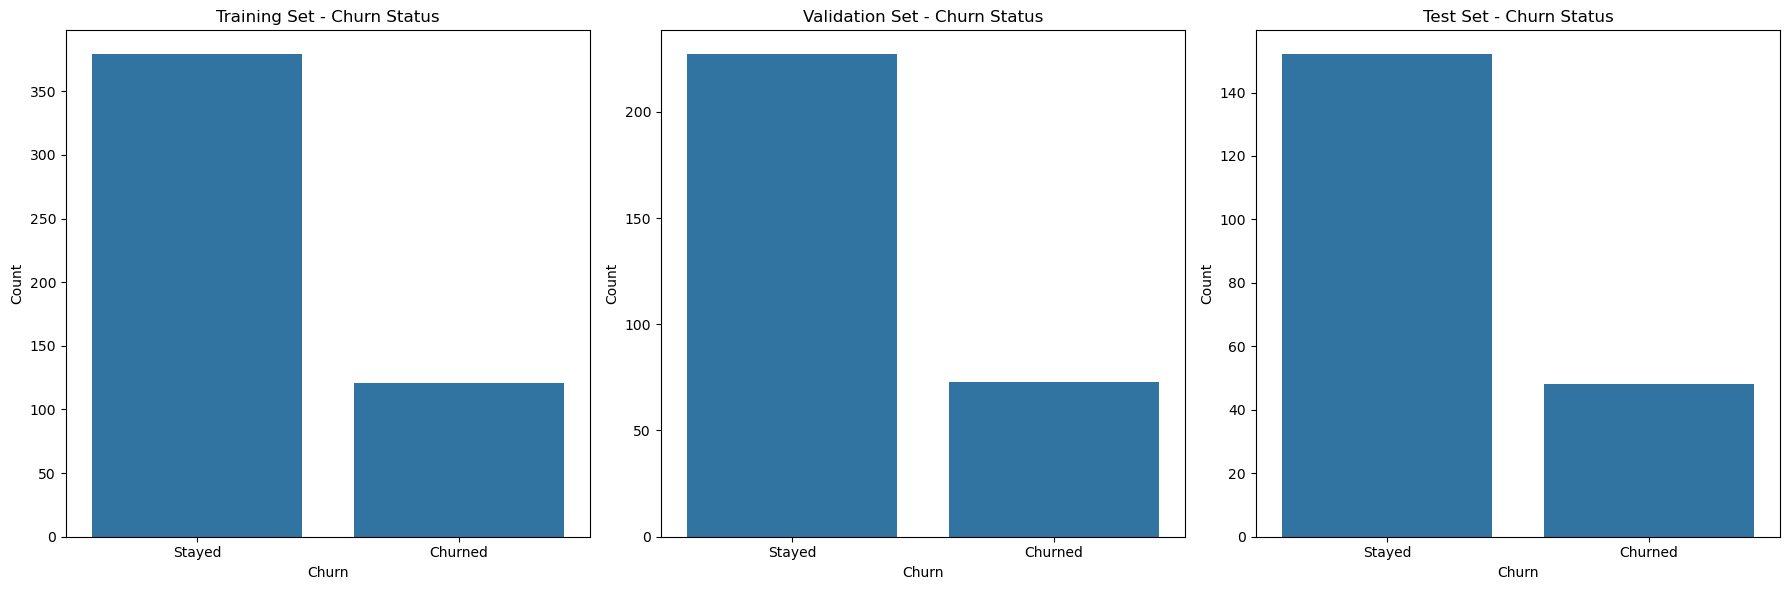

In [11]:
# Combine features and target for plotting
train_data = X_train.copy()
train_data['churn'] = y_train

val_data = X_val.copy()
val_data['churn'] = y_val

test_data = X_test.copy()
test_data['churn'] = y_test

# Plot the distribution of churn
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='churn', ax=axs[0])
axs[0].set_title('Training Set - Churn Status')
axs[0].set_xlabel('Churn')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['Stayed', 'Churned'])

sns.countplot(data=val_data, x='churn', ax=axs[1])
axs[1].set_title('Validation Set - Churn Status')
axs[1].set_xlabel('Churn')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['Stayed', 'Churned'])

sns.countplot(data=test_data, x='churn', ax=axs[2])
axs[2].set_title('Test Set - Churn Status')
axs[2].set_xlabel('Churn')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

# Decision Trees

In [13]:
# Encode categorical variables and train Decision Tree model 

from sklearn.tree import DecisionTreeClassifier

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# One-hot encode
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns
X_train_enc, X_val_enc = X_train_enc.align(X_val_enc, join='left', axis=1, fill_value=0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Controlled Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

# Train model
dt_model.fit(X_train_enc, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


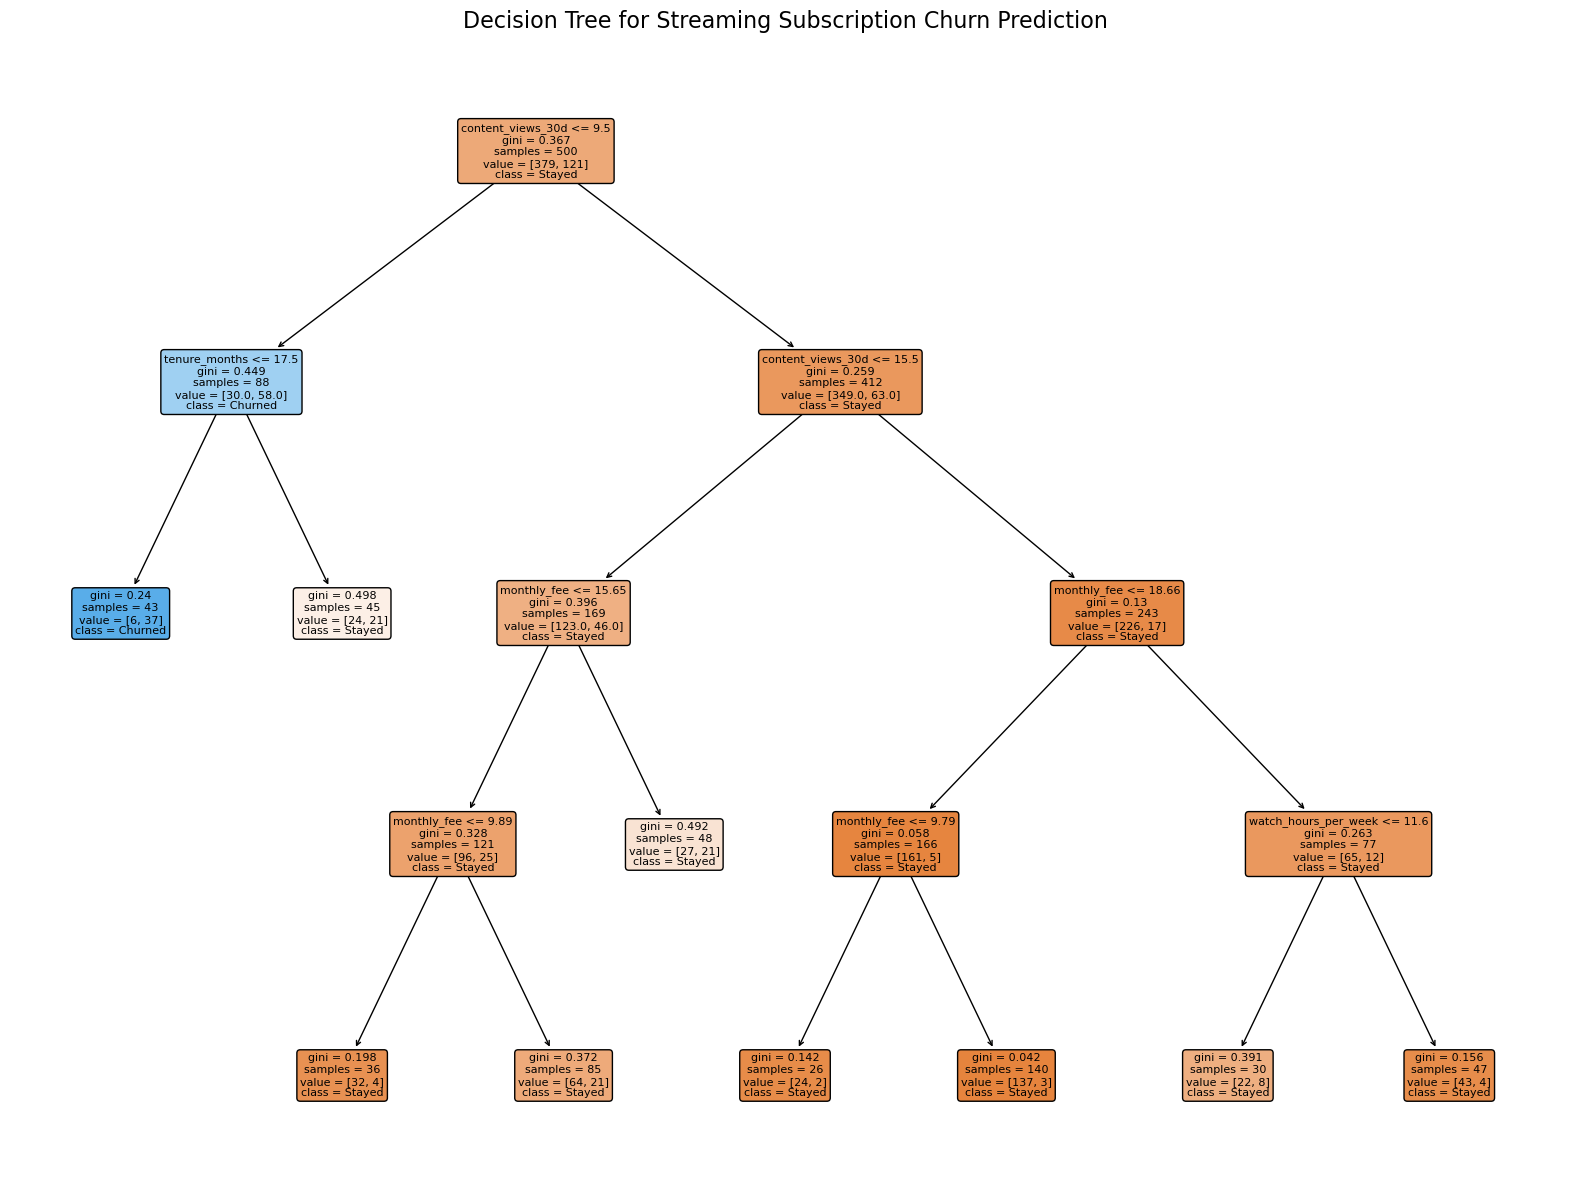

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))

plot_tree(
    dt_model,
    feature_names=X_train_enc.columns,
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree for Streaming Subscription Churn Prediction', fontsize=16)
plt.show()

In [15]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the dt_model.tree_ attribute.

tree_ = dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The decision tree has {number_of_splits} splits (internal nodes).")
print(f"The decision tree has {leaf_nodes} leaves.")


The decision tree has 8 splits (internal nodes).
The decision tree has 9 leaves.


In [16]:
from sklearn.metrics import confusion_matrix

# Predictions on training set
y_train_pred = dt_model.predict(X_train_enc)
cm_train = confusion_matrix(y_train, y_train_pred)

# Predictions on validation set
y_val_pred = dt_model.predict(X_val_enc)
cm_val = confusion_matrix(y_val, y_val_pred)

# Predictions on test set
y_test_pred = dt_model.predict(X_test_enc)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix - Training Set:")
print(cm_train)

print("\nConfusion Matrix - Validation Set:")
print(cm_val)

print("\nConfusion Matrix - Test Set:")
print(cm_test)


Confusion Matrix - Training Set:
[[373   6]
 [ 84  37]]

Confusion Matrix - Validation Set:
[[216  11]
 [ 38  35]]

Confusion Matrix - Test Set:
[[147   5]
 [ 32  16]]


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Training Set
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

print("Training Set Metrics:")
print(f"  Accuracy: {accuracy_train:.4f}")
print(f"  Precision: {precision_train:.4f}")
print(f"  Recall: {recall_train:.4f}")
print(f"  F1-Score: {f1_train:.4f}")

# Calculate metrics for Validation Set
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)

print("\nValidation Set Metrics:")
print(f"  Accuracy: {accuracy_val:.4f}")
print(f"  Precision: {precision_val:.4f}")
print(f"  Recall: {recall_val:.4f}")
print(f"  F1-Score: {f1_val:.4f}")

# Calculate metrics for Test Set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall: {recall_test:.4f}")
print(f"  F1-Score: {f1_test:.4f}")


Training Set Metrics:
  Accuracy: 0.8200
  Precision: 0.8605
  Recall: 0.3058
  F1-Score: 0.4512

Validation Set Metrics:
  Accuracy: 0.8367
  Precision: 0.7609
  Recall: 0.4795
  F1-Score: 0.5882

Test Set Metrics:
  Accuracy: 0.8150
  Precision: 0.7619
  Recall: 0.3333
  F1-Score: 0.4638


## Hyperparameter Tuning

In [19]:
# Define the parameter grid
param_grid = {
    'max_depth': range(2, 30),
    'min_samples_split': range(2, 30),
    'min_samples_leaf': range(1, 20)
}

print("Parameter grid defined:")
print(param_grid)


Parameter grid defined:
{'max_depth': range(2, 30), 'min_samples_split': range(2, 30), 'min_samples_leaf': range(1, 20)}


In [20]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    dt_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit GridSearchCV to the encoded training data
grid_search.fit(X_train_enc, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)


Best hyperparameters found: {'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 19}
Best cross-validation F1-score: 0.5484199471174043


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Retrieve the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Instantiate a new Decision Tree Classifier with the best hyperparameters
tuned_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Train the tuned model on the encoded training dataset
tuned_dt_model.fit(X_train_enc, y_train)

# Make predictions on training set
y_train_pred_tuned = tuned_dt_model.predict(X_train_enc)
cm_train_tuned = confusion_matrix(y_train, y_train_pred_tuned)

# Make predictions on validation set
y_val_pred_tuned = tuned_dt_model.predict(X_val_enc)
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

# Make predictions on test set
y_test_pred_tuned = tuned_dt_model.predict(X_test_enc)
cm_test_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print("\nConfusion Matrix - Tuned Training Set:")
print(cm_train_tuned)

print("\nConfusion Matrix - Tuned Validation Set:")
print(cm_val_tuned)

print("\nConfusion Matrix - Tuned Test Set:")
print(cm_test_tuned)

# Calculate metrics for Training Set
accuracy_train_tuned = accuracy_score(y_train, y_train_pred_tuned)
precision_train_tuned = precision_score(y_train, y_train_pred_tuned)
recall_train_tuned = recall_score(y_train, y_train_pred_tuned)
f1_train_tuned = f1_score(y_train, y_train_pred_tuned)

print("\nTuned Training Set Metrics:")
print(f"  Accuracy: {accuracy_train_tuned:.4f}")
print(f"  Precision: {precision_train_tuned:.4f}")
print(f"  Recall: {recall_train_tuned:.4f}")
print(f"  F1-Score: {f1_train_tuned:.4f}")

# Calculate metrics for Validation Set
accuracy_val_tuned = accuracy_score(y_val, y_val_pred_tuned)
precision_val_tuned = precision_score(y_val, y_val_pred_tuned)
recall_val_tuned = recall_score(y_val, y_val_pred_tuned)
f1_val_tuned = f1_score(y_val, y_val_pred_tuned)

print("\nTuned Validation Set Metrics:")
print(f"  Accuracy: {accuracy_val_tuned:.4f}")
print(f"  Precision: {precision_val_tuned:.4f}")
print(f"  Recall: {recall_val_tuned:.4f}")
print(f"  F1-Score: {f1_val_tuned:.4f}")

# Calculate metrics for Test Set
accuracy_test_tuned = accuracy_score(y_test, y_test_pred_tuned)
precision_test_tuned = precision_score(y_test, y_test_pred_tuned)
recall_test_tuned = recall_score(y_test, y_test_pred_tuned)
f1_test_tuned = f1_score(y_test, y_test_pred_tuned)

print("\nTuned Test Set Metrics:")
print(f"  Accuracy: {accuracy_test_tuned:.4f}")
print(f"  Precision: {precision_test_tuned:.4f}")
print(f"  Recall: {recall_test_tuned:.4f}")
print(f"  F1-Score: {f1_test_tuned:.4f}")


Best hyperparameters: {'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 19}

Confusion Matrix - Tuned Training Set:
[[363  16]
 [ 51  70]]

Confusion Matrix - Tuned Validation Set:
[[209  18]
 [ 30  43]]

Confusion Matrix - Tuned Test Set:
[[134  18]
 [ 24  24]]

Tuned Training Set Metrics:
  Accuracy: 0.8660
  Precision: 0.8140
  Recall: 0.5785
  F1-Score: 0.6763

Tuned Validation Set Metrics:
  Accuracy: 0.8400
  Precision: 0.7049
  Recall: 0.5890
  F1-Score: 0.6418

Tuned Test Set Metrics:
  Accuracy: 0.7900
  Precision: 0.5714
  Recall: 0.5000
  F1-Score: 0.5333


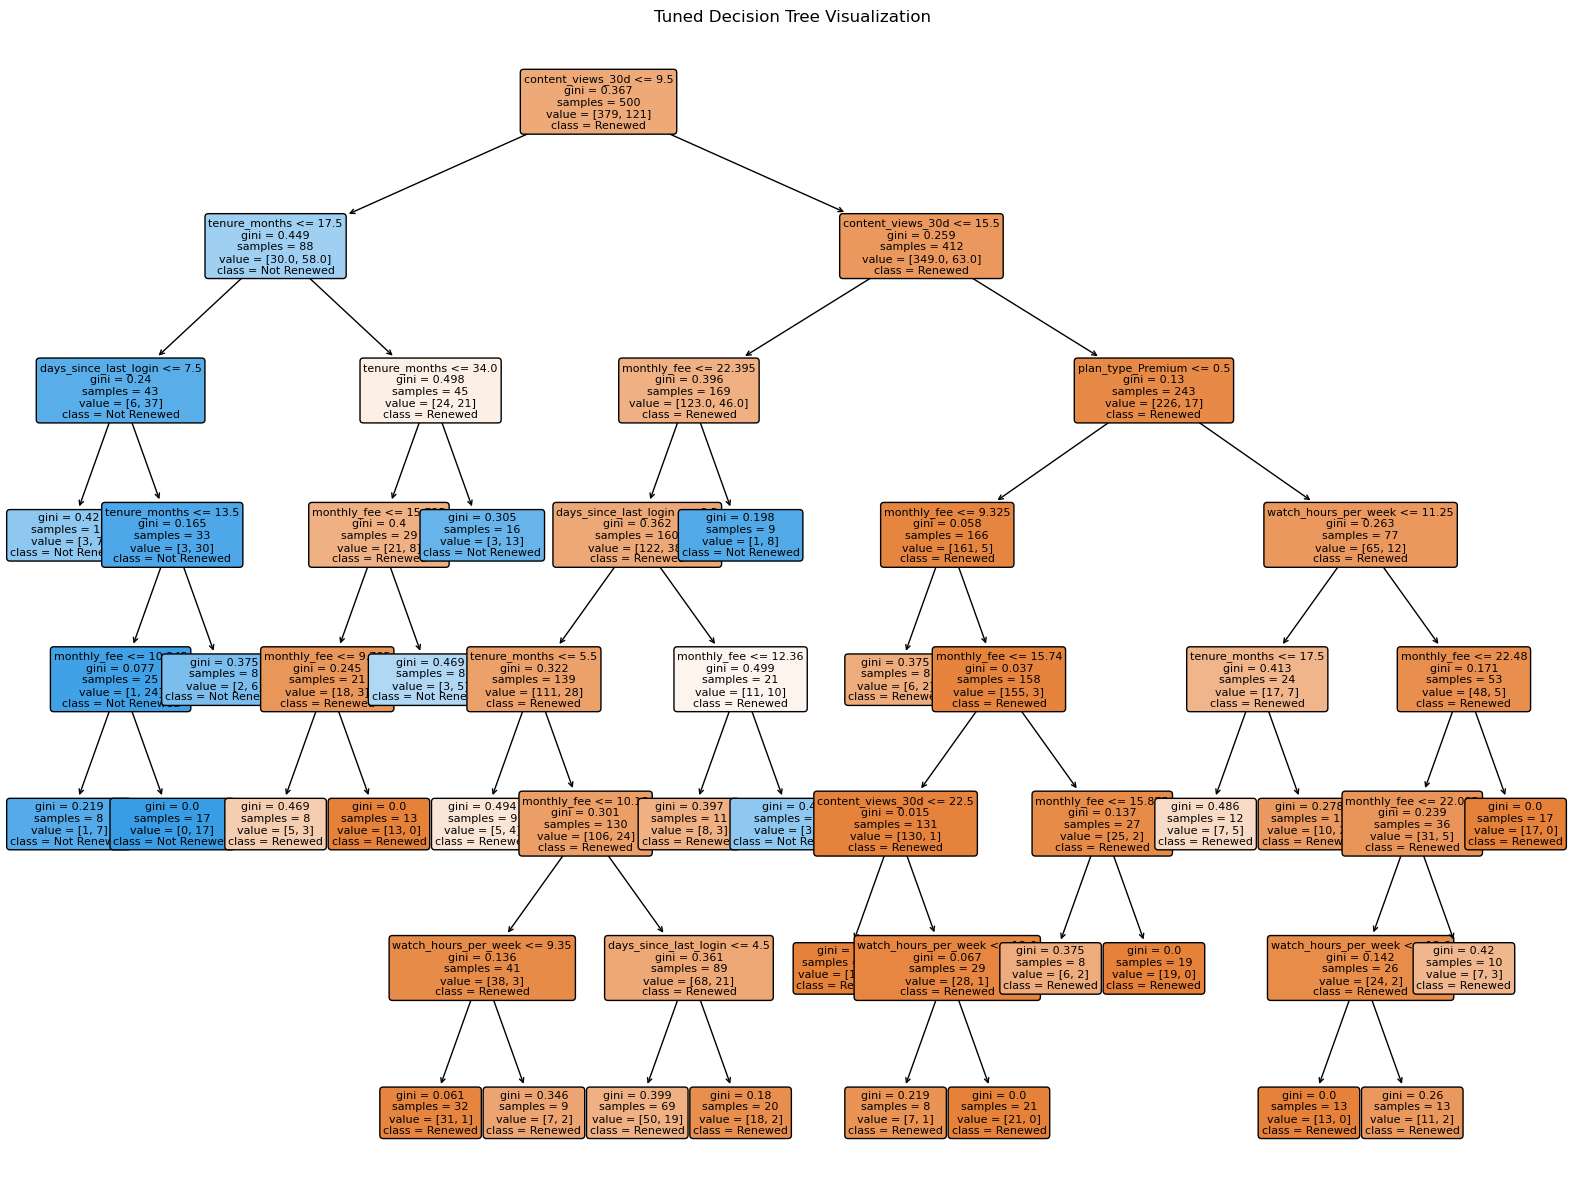

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the tuned decision tree
plot_tree(
    tuned_dt_model,
    feature_names=X_train_enc.columns,          
    class_names=['Renewed', 'Not Renewed'],     
    filled=True,                               
    rounded=True,                               
    fontsize=8                                  
)

plt.title('Tuned Decision Tree Visualization')
plt.show()


In [23]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the tuned_dt_model.tree_ attribute.

tree_ = tuned_dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The tuned decision tree has {number_of_splits} splits (internal nodes).")
print(f"The tuned decision tree has {leaf_nodes} leaves.")


The tuned decision tree has 27 splits (internal nodes).
The tuned decision tree has 28 leaves.


In [24]:
import numpy as np

# Function to extract decision rules and class probabilities
def get_decision_path_rules(tree, feature_names, node_id, current_rule, class_names):
    """Recursively gets the decision path rules and probabilities for each leaf node."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get class counts at the leaf
        value = tree.value[node_id][0]
        total_samples_at_leaf = np.sum(value)

        # Calculate probabilities
        probabilities = value / total_samples_at_leaf

        # Format output
        prob_strings = [
            f"{class_names[i]}: {probabilities[i]:.4f}"
            for i in range(len(class_names))
        ]
        prob_output = ", ".join(prob_strings)

        print(f"Rule: {current_rule} -> Probabilities: {prob_output}")
        return

    # Internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Left child rule
    left_rule = (
        f"{current_rule} AND {feature_name} <= {threshold:.2f}"
        if current_rule else f"{feature_name} <= {threshold:.2f}"
    )
    get_decision_path_rules(tree, feature_names, left_child, left_rule, class_names)

    # Right child rule
    right_rule = (
        f"{current_rule} AND {feature_name} > {threshold:.2f}"
        if current_rule else f"{feature_name} > {threshold:.2f}"
    )
    get_decision_path_rules(tree, feature_names, right_child, right_rule, class_names)


# Get tree structure and correct feature names (encoded)
tree_structure = tuned_dt_model.tree_
feature_names = list(X_train_enc.columns)

# Correct class names for your target
class_names = ['Renewed', 'Not Renewed']

print("Logical rules and probabilities for each leaf of the tuned decision tree:")

# Start recursion from root node
get_decision_path_rules(tree_structure, feature_names, 0, "", class_names)


Logical rules and probabilities for each leaf of the tuned decision tree:
Rule: content_views_30d <= 9.50 AND tenure_months <= 17.50 AND days_since_last_login <= 7.50 -> Probabilities: Renewed: 0.3000, Not Renewed: 0.7000
Rule: content_views_30d <= 9.50 AND tenure_months <= 17.50 AND days_since_last_login > 7.50 AND tenure_months <= 13.50 AND monthly_fee <= 10.25 -> Probabilities: Renewed: 0.1250, Not Renewed: 0.8750
Rule: content_views_30d <= 9.50 AND tenure_months <= 17.50 AND days_since_last_login > 7.50 AND tenure_months <= 13.50 AND monthly_fee > 10.25 -> Probabilities: Renewed: 0.0000, Not Renewed: 1.0000
Rule: content_views_30d <= 9.50 AND tenure_months <= 17.50 AND days_since_last_login > 7.50 AND tenure_months > 13.50 -> Probabilities: Renewed: 0.2500, Not Renewed: 0.7500
Rule: content_views_30d <= 9.50 AND tenure_months > 17.50 AND tenure_months <= 34.00 AND monthly_fee <= 15.72 AND monthly_fee <= 9.78 -> Probabilities: Renewed: 0.6250, Not Renewed: 0.3750
Rule: content_views

In [25]:
import pandas as pd

# Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = tuned_dt_model.feature_importances_

# Get the feature names from the encoded training data
feature_names_dt = X_train_enc.columns

# Create a pandas Series to view feature importances with names
feature_importance_series_tuned_dt = pd.Series(
    feature_importances_tuned_dt,
    index=feature_names_dt
)

# Sort feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Decision Tree:")
print(sorted_feature_importances_tuned_dt)


Feature Importances for Tuned Decision Tree:
content_views_30d        0.523601
monthly_fee              0.205052
tenure_months            0.175207
days_since_last_login    0.050544
watch_hours_per_week     0.026403
plan_type_Premium        0.019193
num_profiles             0.000000
plan_type_Standard       0.000000
dtype: float64


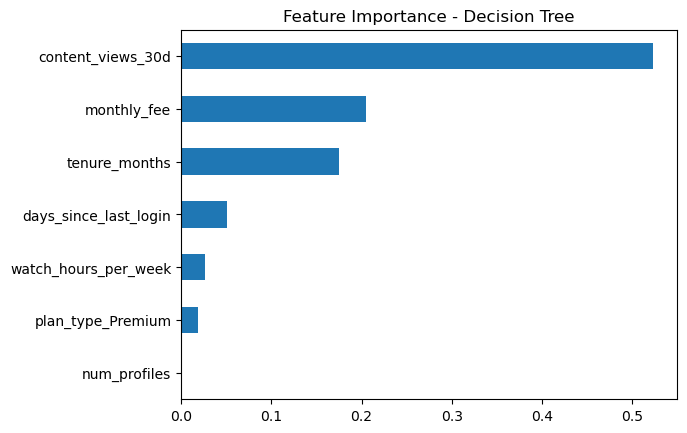

In [47]:
import matplotlib.pyplot as plt

sorted_feature_importances_tuned_dt.head(7).plot(kind='barh')
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()